# Práctica de Laboratorio: AES y Modos de Operación sobre Imágenes BMP
**Objetivo:** Comprender de forma visual y práctica cómo funcionan los modos de operación ECB, CBC y CTR al aplicarse sobre una imagen BMP

## 1. Arquitectura del Archivo BMP y Configuración
Para poder visualizar los efectos del cifrado, no podemos cifrar el archivo completo. Los archivos BMP tienen una estructura específica donde los primeros 54 bytes corresponden a la cabecera (header) que contiene metadatos vitales (dimensiones, paleta de colores)Si ciframos esta sección, el sistema operativo no reconocerá el archivo como una imagen

Por lo tanto, la arquitectura de nuestra solución dividirá el archivo: preservaremos los primeros 54 bytes intactos y aplicaremos las transformaciones criptográficas únicamente al cuerpo (los píxeles)

In [1]:
import json
from Crypto.Cipher import AES
from Crypto.Random import get_random_bytes

def pad(data, block_size=16):
   
    pad_len = block_size - (len(data) % block_size)
    return data + bytes([pad_len]) * pad_len

def read_bmp(file_path):
    
    with open(file_path, "rb") as f:
        bmp = f.read()
        header = bmp[:54]
        body = bmp[54:]
    return header, body

def write_bmp(file_path, header, body):
    
    with open(file_path, "wb") as f:
        f.write(header + body)

## 2. Gestión del Estado Criptográfico (Material)
En sistemas de producción, las llaves y vectores de inicialización nunca se "queman" en el código. Aquí implementamos un gestor de estado que genera entropía real usando `get_random_bytes` y persiste estos parámetros en un archivo JSON. 

* **Key:** 16 bytes para AES-128.
* **IV:** 16 bytes, requerido para el modo CBC.
* **Nonce:** 8 bytes, requerido para el modo CTR.

In [2]:
def generate_crypto_material():
    material = {
        "key": get_random_bytes(16).hex(),
        "iv": get_random_bytes(16).hex(),
        "nonce": get_random_bytes(8).hex()
    }
    return material

def save_crypto_material(material, output_file):
    with open(output_file, "w") as f:
        json.dump(material, f, indent=4)

def load_crypto_material(input_file):
    with open(input_file, "r") as f:
        material = json.load(f)
    return material

# Ejecución: Generar y guardar
archivo_claves = "mis_claves_MATRICULA.json"
material_cripto = generate_crypto_material()
save_crypto_material(material_cripto, archivo_claves)
print(f"[+] Material criptográfico guardado en: {archivo_claves}")

[+] Material criptográfico guardado en: mis_claves_MATRICULA.json


## 3. Pipeline de Cifrado y Análisis de Modos
Esta función actúa como un enrutador (router) aplicando el modo de operación solicitado.

**Teoría de Modos de Operación:**
* **ECB (Electronic Codebook):** Es determinista. Bloques de texto plano idénticos producen bloques cifrados idénticos. Esto significa que los patrones visuales (como áreas de un mismo color en la imagen) seguirán siendo visibles.
* **CBC (Cipher Block Chaining):** Introduce aleatoriedad con el IV y encadena los bloques mediante operaciones XOR. El resultado es visualmente indistinguible del ruido aleatorio. Requiere padding.
* **CTR (Counter):** Convierte el cifrador de bloques en un cifrador de flujo usando un Nonce y un contador. No requiere padding porque opera byte a byte.

[+] ECB cifrado guardado en: ecb.bmp
[+] CBC cifrado guardado en: cbc.bmp
[+] CTR cifrado guardado en: ctr.bmp

--- Análisis Visual de los Modos de Operación ---

1. Modo ECB (Electronic Codebook):


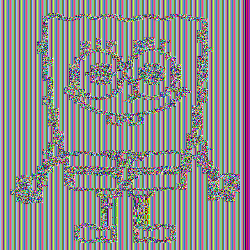


2. Modo CBC (Cipher Block Chaining):


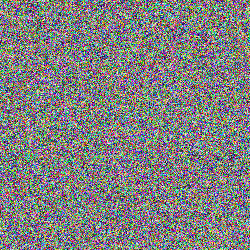


3. Modo CTR (Counter):


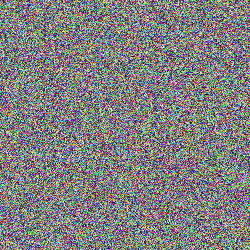

In [6]:
from PIL import Image
from IPython.display import display

def encrypt_bmp(input_file, output_file, mode_name, material):
    header, body = read_bmp(input_file)
    key = bytes.fromhex(material["key"])
    
    if mode_name == "ECB":
        cipher = AES.new(key, AES.MODE_ECB)
        body_padded = pad(body)
        encrypted = cipher.encrypt(body_padded)
        encrypted = encrypted[:len(body)] 
        
    elif mode_name == "CBC":
        iv = bytes.fromhex(material["iv"])
        cipher = AES.new(key, AES.MODE_CBC, iv=iv)
        body_padded = pad(body)
        encrypted = cipher.encrypt(body_padded)
        encrypted = encrypted[:len(body)]
        
    elif mode_name == "CTR":
        nonce = bytes.fromhex(material["nonce"])
        cipher = AES.new(key, AES.MODE_CTR, nonce=nonce)
        encrypted = cipher.encrypt(body)
        
    else:
        raise ValueError("Modo no soportado")
        
    write_bmp(output_file, header, encrypted)
    print(f"[+] {mode_name} cifrado guardado en: {output_file}")

# 1. Ejecución del cifrado
material = load_crypto_material(archivo_claves)
encrypt_bmp("input.bmp", "ecb.bmp", "ECB", material)
encrypt_bmp("input.bmp", "cbc.bmp", "CBC", material)
encrypt_bmp("input.bmp", "ctr.bmp", "CTR", material)

# 2. Despliegue visual en el Notebook
print("\n--- Análisis Visual de los Modos de Operación ---")

print("\n1. Modo ECB (Electronic Codebook):")
display(Image.open("ecb.bmp"))

print("\n2. Modo CBC (Cipher Block Chaining):")
display(Image.open("cbc.bmp"))

print("\n3. Modo CTR (Counter):")
display(Image.open("ctr.bmp"))

## Preguntas de observacion

Cual de los 3 modos deja ver mas estructura de la imagen original? ECB

Cual parece producir una salida mas cercana a ruido aleatorio?CTR

Que sugiere esto acerca de la seguridad de ECB frente a CBC y CTR? ECB es menos eficiiente en terminos de encriptacion contra los otros 2

## 4. Pipeline de Descifrado
El proceso inverso. Es crucial destacar que sin la llave criptográfica correcta (y los parámetros de estado correspondientes), la matemática de las permutaciones de AES hace que sea computacionalmente inviable revertir la imagen a su estado original.

[+] ECB descifrado guardado en: ecb_descifrada.bmp
[+] CBC descifrado guardado en: cbc_descifrada.bmp
[+] CTR descifrado guardado en: ctr_descifrada.bmp

--- Verificación de Integridad (Imágenes Recuperadas) ---

1. Imagen recuperada de ECB:


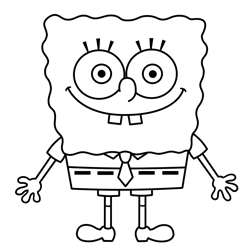


2. Imagen recuperada de CBC:


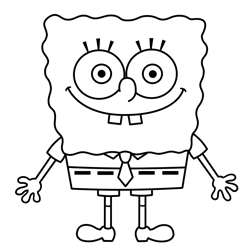


3. Imagen recuperada de CTR:


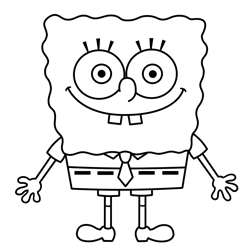

In [7]:
from PIL import Image
from IPython.display import display

def decrypt_bmp(input_file, output_file, mode_name, material):
    header, body = read_bmp(input_file)
    key = bytes.fromhex(material["key"])
    
    if mode_name == "ECB":
        cipher = AES.new(key, AES.MODE_ECB)
        decrypted = cipher.decrypt(pad(body))
        decrypted = decrypted[:len(body)]
        
    elif mode_name == "CBC":
        iv = bytes.fromhex(material["iv"])
        cipher = AES.new(key, AES.MODE_CBC, iv=iv)
        decrypted = cipher.decrypt(pad(body))
        decrypted = decrypted[:len(body)]
        
    elif mode_name == "CTR":
        nonce = bytes.fromhex(material["nonce"])
        cipher = AES.new(key, AES.MODE_CTR, nonce=nonce)
        decrypted = cipher.decrypt(body)
        
    else:
        raise ValueError("Modo no soportado")
        
    write_bmp(output_file, header, decrypted)
    print(f"[+] {mode_name} descifrado guardado en: {output_file}")

# 1. Ejecución del descifrado
decrypt_bmp("ecb.bmp", "ecb_descifrada.bmp", "ECB", material)
decrypt_bmp("cbc.bmp", "cbc_descifrada.bmp", "CBC", material)
decrypt_bmp("ctr.bmp", "ctr_descifrada.bmp", "CTR", material)

# 2. Despliegue visual en el Notebook
print("\n--- Verificación de Integridad (Imágenes Recuperadas) ---")

print("\n1. Imagen recuperada de ECB:")
display(Image.open("ecb_descifrada.bmp"))

print("\n2. Imagen recuperada de CBC:")
display(Image.open("cbc_descifrada.bmp"))

print("\n3. Imagen recuperada de CTR:")
display(Image.open("ctr_descifrada.bmp"))

## Verificacion

Las imageenes coinciden visualmente con la original? correcto

Porque fue posible recuperar la imagen? Llaves chidas

## 5. Tolerancia a Fallos y Propagación de Errores (Bit Flipping)
En redes reales, los bits pueden corromperse. Aquí alteramos deliberadamente el byte en la posición 2000 (muy lejos de la cabecera de 54 bytes) cambiando su valor a `0xFF`.

**Teoría de propagación:**
* **ECB:** Arruina exactamente el bloque de 16 bytes al que pertenece ese byte.
* **CBC:** El error se propaga fuertemente. Arruina por completo el bloque actual y modifica un byte específico en el siguiente bloque debido al XOR del encadenamiento.
* **CTR:** Tiene un confinamiento de error perfecto. Como opera haciendo XOR directamente con el flujo de datos, un bit alterado en el cifrado resulta en exactamente un bit alterado en el descifrado.

In [5]:
def flip_byte(file_path, output_path, position):
    """Modifica artificialmente un byte específico para simular corrupción."""
    with open(file_path, "rb") as f:
        data = bytearray(f.read())
        
    print(f"[{file_path}] Byte original: {data[position]}")
    data[position] = 0xFF
    print(f"[{file_path}] Byte modificado: {data[position]}")
    
    with open(output_path, "wb") as f:
        f.write(data)
    print(f"[+] Archivo modificado guardado en: {output_path}\n")

# Ejecución: Alterar el byte 2000
flip_byte("ecb.bmp", "ecb_mod.bmp", 2000)
flip_byte("cbc.bmp", "cbc_mod.bmp", 2000)
flip_byte("ctr.bmp", "ctr_mod.bmp", 2000)

# Descifrar los archivos alterados para observar el daño
decrypt_bmp("ecb_mod.bmp", "ecb_mod_descifrada.bmp", "ECB", material)
decrypt_bmp("cbc_mod.bmp", "cbc_mod_descifrada.bmp", "CBC", material)
decrypt_bmp("ctr_mod.bmp", "ctr_mod_descifrada.bmp", "CTR", material)

[ecb.bmp] Byte original: 24
[ecb.bmp] Byte modificado: 255
[+] Archivo modificado guardado en: ecb_mod.bmp

[cbc.bmp] Byte original: 91
[cbc.bmp] Byte modificado: 255
[+] Archivo modificado guardado en: cbc_mod.bmp

[ctr.bmp] Byte original: 134
[ctr.bmp] Byte modificado: 255
[+] Archivo modificado guardado en: ctr_mod.bmp

[+] ECB descifrado guardado en: ecb_mod_descifrada.bmp
[+] CBC descifrado guardado en: cbc_mod_descifrada.bmp
[+] CTR descifrado guardado en: ctr_mod_descifrada.bmp


## Preguntas de analisis

6. Qué efecto visual tuvo el cambio de un byte en ECB?
7. Qué diferencia observaste en CBC?
8. Qué diferencia observaste en CTR?
9. Qué modo propagó más el error?
10. Qué modo localizó mejor el error?

## Intercambio entre companeros

--- Parte 7.1: Descifrado con las llaves del compañero ---
[+] CBC descifrado guardado en: imagen_companero_descifrada.bmp

[+] Éxito: Imagen descifrada con la llave correcta. Desplegando...


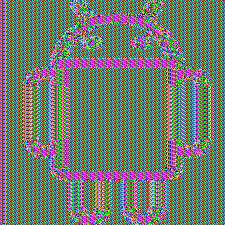


---------------------------------------------------------
--- Parte 7.2: Prueba adicional con llave incorrecta ---
[+] CBC descifrado guardado en: fallo_descifrado.bmp

[+] Operación finalizada (llave incorrecta). Desplegando resultado...


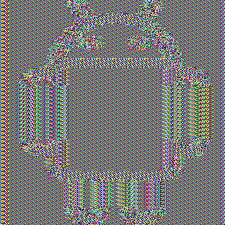

In [8]:
from IPython.display import display
from PIL import Image

print("--- Parte 7.1: Descifrado con las llaves del compañero ---")
# ACTUALIZA ESTOS NOMBRES con los archivos reales que te pasaron
archivo_llave_companero = "claves_companero.json" 
imagen_companero = "imagen_companero.bmp"

try:
    material_companero = load_crypto_material(archivo_llave_companero)
    # Desciframos usando el material correcto del compañero
    decrypt_bmp(imagen_companero, "imagen_companero_descifrada.bmp", "CBC", material_companero)
    
    print("\n[+] Éxito: Imagen descifrada con la llave correcta. Desplegando...")
    display(Image.open("imagen_companero_descifrada.bmp"))
except FileNotFoundError:
    print(f"\n[!] Error: No se encontró el archivo. Verifica los nombres: {archivo_llave_companero} y {imagen_companero}")


print("\n---------------------------------------------------------")
print("--- Parte 7.2: Prueba adicional con llave incorrecta ---")

# ACTUALIZA ESTE NOMBRE con tu archivo de llaves original
mis_claves = "mis_claves_MATRICULA.json"

try:
    mis_materiales = load_crypto_material(mis_claves)
    # Intentamos descifrar la imagen del compañero usando TUS llaves
    decrypt_bmp(imagen_companero, "fallo_descifrado.bmp", "CBC", mis_materiales)
    
    print("\n[+] Operación finalizada (llave incorrecta). Desplegando resultado...")
    display(Image.open("fallo_descifrado.bmp"))
except Exception as e:
    print(f"\n[!] Ocurrió un error: {e}")

## Conclusiones